In [4]:
import tensorflow as tf
tf.config.list_physical_devices('GPU')

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

In [ ]:
!nvidia-smi

Fri Mar  6 14:49:31 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   53C    P8             11W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import shutil
import uuid

dataset_path = "/content/drive/MyDrive/dataset"

for category in os.listdir(dataset_path):
    category_path = os.path.join(dataset_path, category)

    for subfolder in os.listdir(category_path):
        sub_path = os.path.join(category_path, subfolder)

        if os.path.isdir(sub_path):

            for file in os.listdir(sub_path):

                src = os.path.join(sub_path, file)

                # create unique filename
                new_name = str(uuid.uuid4()) + ".jpg"
                dst = os.path.join(category_path, new_name)

                shutil.move(src, dst)

            os.rmdir(sub_path)

print("Dataset structure fixed successfully!")

Dataset structure fixed successfully!


In [ ]:
import os

for folder in os.listdir("/content/drive/MyDrive/dataset"):
    print(folder, "->", len(os.listdir(f"/content/drive/MyDrive/dataset/{folder}")))

Recyclable -> 630
Hazardous -> 1537
Biodegradable -> 647
.ipynb_checkpoints -> 0


In [ ]:
# 1. BETTER DATA SPLITTING - Split by samples, not batches
import os
import cv2
import numpy as np
from PIL import Image
import tensorflow as tf
from sklearn.model_selection import train_test_split

In [ ]:
# First, thoroughly clean the dataset
import os
import cv2
import numpy as np
from PIL import Image
import imghdr
import traceback
import warnings
warnings.filterwarnings('ignore')  # Temporarily ignore warnings during cleaning

def aggressive_dataset_cleaner(dataset_path):
    """
    Aggressively clean dataset by testing multiple loading methods
    and removing any file that causes warnings or errors
    """
    removed_count = 0
    warning_count = 0

    # Valid image extensions
    valid_extensions = ('.jpg', '.jpeg', '.png', '.bmp', '.gif', '.tiff', '.webp')

    print("Starting aggressive dataset cleaning...")
    print("-" * 50)

    for root, dirs, files in os.walk(dataset_path):
        for file in files:
            file_path = os.path.join(root, file)
            file_size = os.path.getsize(file_path)

            # Remove empty files
            if file_size == 0:
                print(f"Removing empty file: {file}")
                os.remove(file_path)
                removed_count += 1
                continue

            # Check extension
            if not file.lower().endswith(valid_extensions):
                print(f"Removing file with invalid extension: {file}")
                os.remove(file_path)
                removed_count += 1
                continue

            # Test 1: Try with imghdr
            try:
                image_type = imghdr.what(file_path)
                if image_type not in ['jpeg', 'png', 'gif', 'bmp', 'tiff']:
                    print(f"Removing file with invalid image type ({image_type}): {file}")
                    os.remove(file_path)
                    removed_count += 1
                    continue
            except:
                pass

            # Test 2: Try with PIL
            try:
                # Try to open and verify
                with Image.open(file_path) as img:
                    img.verify()

                # Try to actually load and convert
                with Image.open(file_path) as img:
                    # Try to convert to RGB
                    img = img.convert('RGB')

                    # Check dimensions
                    if img.size[0] < 50 or img.size[1] < 50:
                        print(f"Removing too small image ({img.size}): {file}")
                        os.remove(file_path)
                        removed_count += 1
                        continue

                    # Try to get pixel data
                    np.array(img)

            except Exception as e:
                print(f"Removing PIL-corrupted file: {file} - Error: {str(e)[:50]}")
                os.remove(file_path)
                removed_count += 1
                continue

            # Test 3: Try with OpenCV
            try:
                img = cv2.imread(file_path)
                if img is None:
                    print(f"Removing OpenCV-corrupted file: {file}")
                    os.remove(file_path)
                    removed_count += 1
                    continue

                # Check dimensions
                if img.shape[0] < 50 or img.shape[1] < 50:
                    print(f"Removing too small image (OpenCV): {file}")
                    os.remove(file_path)
                    removed_count += 1
                    continue

            except Exception as e:
                print(f"Removing OpenCV-error file: {file} - Error: {str(e)[:50]}")
                os.remove(file_path)
                removed_count += 1
                continue

            # Test 4: Try with TensorFlow
            try:
                image_data = tf.io.read_file(file_path)
                tf.image.decode_image(image_data, channels=3)
            except Exception as e:
                print(f"Removing TensorFlow-corrupted file: {file} - Error: {str(e)[:50]}")
                os.remove(file_path)
                removed_count += 1
                continue

            # If we got here, the file is good
            if removed_count % 10 == 0 and removed_count > 0:
                print(f"Progress: {removed_count} files removed so far...")

    print("-" * 50)
    print(f"Cleaning complete! Removed {removed_count} problematic files.")
    return removed_count



/tmp/ipykernel_680/117635270.py:6: DeprecationWarning: 'imghdr' is deprecated and slated for removal in Python 3.13
  import imghdr


In [ ]:
# Run the aggressive cleaner
dataset_path = "/content/drive/MyDrive/dataset"
removed = aggressive_dataset_cleaner(dataset_path)
print(f"Total files removed: {removed}")

Starting aggressive dataset cleaning...
--------------------------------------------------
--------------------------------------------------
Cleaning complete! Removed 0 problematic files.
Total files removed: 0


In [ ]:
# Now verify what's left
print("\n" + "="*50)
print("Dataset summary after cleaning:")
print("="*50)

for class_name in sorted(os.listdir(dataset_path)):
    class_path = os.path.join(dataset_path, class_name)
    if os.path.isdir(class_path):
        image_count = len([f for f in os.listdir(class_path)
                          if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp', '.gif'))])
        print(f"{class_name}: {image_count} images")


Dataset summary after cleaning:
.ipynb_checkpoints: 0 images
Biodegradable: 647 images
Hazardous: 1537 images
Recyclable: 630 images


In [ ]:
import tensorflow as tf
import numpy as np
import os
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

In [ ]:
# Configuration
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
dataset_path = "/content/drive/MyDrive/dataset"

In [ ]:
# 1. Get class names and counts
class_names = sorted(['Biodegradable', 'Hazardous', 'Recyclable'])
print("Classes:", class_names)
print(f"Biodegradable: 647 images")
print(f"Hazardous: 1537 images")
print(f"Recyclable: 630 images")

Classes: ['Biodegradable', 'Hazardous', 'Recyclable']
Biodegradable: 647 images
Hazardous: 1537 images
Recyclable: 630 images


In [ ]:
# 2. Collect file paths
file_paths = []
labels = []

In [ ]:
for idx,cls in enumerate(class_names):
    path = os.path.join(dataset_path,cls)
    for img in os.listdir(path):
        file_paths.append(os.path.join(path,img))
        labels.append(idx)

In [ ]:
# 3. Stratified split (maintains class distribution)
X_train,X_temp,y_train,y_temp = train_test_split(
    file_paths,labels,
    test_size=0.3,
    stratify=labels,
    random_state=42)

X_val,X_test,y_val,y_test = train_test_split(
    X_temp,y_temp,
    test_size=0.5,
    stratify=y_temp,
    random_state=42)

In [ ]:
# class weights
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(labels),
    y=labels)

class_weight_dict = {i:class_weights[i] for i in range(3)}

In [ ]:
# dataset loader
def load_image(path,label):

    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img,channels=3)
    img = tf.image.resize(img,IMG_SIZE)
    img = preprocess_input(img)

    return img,label

In [ ]:
# augmentation
def augment(img,label):

    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_flip_up_down(img)
    img = tf.image.random_brightness(img,0.2)
    img = tf.image.random_contrast(img,0.8,1.2)

    return img,label


In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = tf.data.Dataset.from_tensor_slices((X_train,y_train))
train_ds = train_ds.map(load_image,num_parallel_calls=AUTOTUNE)
train_ds = train_ds.map(augment,num_parallel_calls=AUTOTUNE)
train_ds = train_ds.shuffle(2000).batch(BATCH_SIZE).prefetch(AUTOTUNE)

val_ds = tf.data.Dataset.from_tensor_slices((X_val,y_val))
val_ds = val_ds.map(load_image,num_parallel_calls=AUTOTUNE)
val_ds = val_ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

test_ds = tf.data.Dataset.from_tensor_slices((X_test,y_test))
test_ds = test_ds.map(load_image,num_parallel_calls=AUTOTUNE)
test_ds = test_ds.batch(BATCH_SIZE)

In [ ]:

# MODEL
base_model = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3))

base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)
x = Dense(256,activation='relu')(x)
x = Dropout(0.5)(x)

outputs = Dense(3,activation='softmax')(x)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [ ]:
model = Model(base_model.input,outputs)

model.compile(
    optimizer=Adam(learning_rate=3e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'])

callbacks = [
EarlyStopping(patience=8,restore_best_weights=True),
ReduceLROnPlateau(patience=4,factor=0.3),
ModelCheckpoint("best_model.h5",save_best_only=True)
]

In [ ]:
print("Stage 1 Training")

history1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    class_weight=class_weight_dict,
    callbacks=callbacks)

Stage 1 Training
Epoch 1/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 325ms/step - accuracy: 0.4415 - loss: 1.4110

62/62 ━━━━━━━━━━━━━━━━━━━━ 114s 755ms/step - accuracy: 0.4429 - loss: 1.4070 - val_accuracy: 0.7393 - val_loss: 0.6491 - learning_rate: 3.0000e-04
Epoch 2/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.7061 - loss: 0.7240

62/62 ━━━━━━━━━━━━━━━━━━━━ 47s 221ms/step - accuracy: 0.7062 - loss: 0.7241 - val_accuracy: 0.7654 - val_loss: 0.5821 - learning_rate: 3.0000e-04
Epoch 3/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.7600 - loss: 0.5705

62/62 ━━━━━━━━━━━━━━━━━━━━ 76s 141ms/step - accuracy: 0.7599 - loss: 0.5709 - val_accuracy: 0.7915 - val_loss: 0.5063 - learning_rate: 3.0000e-04
Epoch 4/20
61/62 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.7847 - loss: 0.5174

62/62 ━━━━━━━━━━━━━━━━━━━━ 44s 217ms/step - accuracy: 0.7846 - loss: 0.5173 - val_accuracy: 0.7844 - val_loss: 0.5022 - learning_rate: 3.0000e-04
Epoch 5/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.8236 - loss: 0.4026

62/62 ━━━━━━━━━━━━━━━━━━━━ 40s 147ms/step - accuracy: 0.8232 - loss: 0.4031 - val_accuracy: 0.7986 - val_loss: 0.4868 - learning_rate: 3.0000e-04
Epoch 6/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 41s 157ms/step - accuracy: 0.8185 - loss: 0.4056 - val_accuracy: 0.7962 - val_loss: 0.5112 - learning_rate: 3.0000e-04
Epoch 7/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 41s 159ms/step - accuracy: 0.8531 - loss: 0.3478 - val_accuracy: 0.8009 - val_loss: 0.5071 - learning_rate: 3.0000e-04
Epoch 8/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 44s 207ms/step - accuracy: 0.8574 - loss: 0.3257 - val_accuracy: 0.7962 - val_loss: 0.4965 - learning_rate: 3.0000e-04
Epoch 9/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 45s 208ms/step - accuracy: 0.8697 - loss: 0.3075 - val_accuracy: 0.8152 - val_loss: 0.4919 - learning_rate: 3.0000e-04
Epoch 10/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 41s 158ms/step - accuracy: 0.8678 - loss: 0.2909 - val_accuracy: 0.8128 - val_loss: 0.4931 - learning_rate: 9.0000e-05
Epoch 11/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 43s 207ms/step - accuracy: 0.

62/62 ━━━━━━━━━━━━━━━━━━━━ 44s 215ms/step - accuracy: 0.8981 - loss: 0.2438 - val_accuracy: 0.8104 - val_loss: 0.4854 - learning_rate: 9.0000e-05
Epoch 13/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.8834 - loss: 0.2523

62/62 ━━━━━━━━━━━━━━━━━━━━ 44s 215ms/step - accuracy: 0.8834 - loss: 0.2522 - val_accuracy: 0.8128 - val_loss: 0.4807 - learning_rate: 9.0000e-05
Epoch 14/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.9015 - loss: 0.2329

62/62 ━━━━━━━━━━━━━━━━━━━━ 42s 170ms/step - accuracy: 0.9015 - loss: 0.2329 - val_accuracy: 0.8128 - val_loss: 0.4784 - learning_rate: 9.0000e-05
Epoch 15/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 44s 207ms/step - accuracy: 0.8751 - loss: 0.2600 - val_accuracy: 0.8128 - val_loss: 0.4891 - learning_rate: 9.0000e-05
Epoch 16/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 41s 158ms/step - accuracy: 0.9074 - loss: 0.2188 - val_accuracy: 0.8199 - val_loss: 0.4877 - learning_rate: 9.0000e-05
Epoch 17/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 44s 208ms/step - accuracy: 0.9029 - loss: 0.2309 - val_accuracy: 0.8175 - val_loss: 0.4899 - learning_rate: 9.0000e-05
Epoch 18/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 41s 160ms/step - accuracy: 0.9055 - loss: 0.2304 - val_accuracy: 0.8152 - val_loss: 0.4845 - learning_rate: 9.0000e-05
Epoch 19/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 43s 206ms/step - accuracy: 0.8988 - loss: 0.2158 - val_accuracy: 0.8128 - val_loss: 0.4845 - learning_rate: 2.7000e-05
Epoch 20/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 44s 207ms/step - accuracy

In [ ]:
# Fine tuning
base_model.trainable = True

for layer in base_model.layers[:-40]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-6),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)



In [ ]:
print("Stage 2 Fine Tuning")

history2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    class_weight=class_weight_dict,
    callbacks=callbacks)


Stage 2 Fine Tuning
Epoch 1/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 101s 615ms/step - accuracy: 0.8080 - loss: 0.4419 - val_accuracy: 0.7962 - val_loss: 0.5236 - learning_rate: 1.0000e-06
Epoch 2/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 41s 146ms/step - accuracy: 0.8181 - loss: 0.4284 - val_accuracy: 0.7891 - val_loss: 0.5360 - learning_rate: 1.0000e-06
Epoch 3/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 41s 136ms/step - accuracy: 0.8244 - loss: 0.4278 - val_accuracy: 0.7915 - val_loss: 0.5437 - learning_rate: 1.0000e-06
Epoch 4/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 46s 219ms/step - accuracy: 0.8340 - loss: 0.4424 - val_accuracy: 0.7891 - val_loss: 0.5492 - learning_rate: 1.0000e-06
Epoch 5/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 45s 216ms/step - accuracy: 0.8163 - loss: 0.4589 - val_accuracy: 0.7938 - val_loss: 0.5509 - learning_rate: 1.0000e-06
Epoch 6/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 45s 217ms/step - accuracy: 0.8204 - loss: 0.4751 - val_accuracy: 0.7938 - val_loss: 0.5514 - learning_rate: 3.0000e-07
Epoch 7/20
62/62 ━━━━━━━━━━━━━━━━━━━━

In [ ]:
model.load_weights("best_model.h5")

In [ ]:
test_loss, test_acc = model.evaluate(test_ds)

print(f"\nTest Accuracy: {test_acc:.4f}")

14/14 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step - accuracy: 0.8423 - loss: 0.4343

Test Accuracy: 0.8156


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

y_true = []
y_pred = []

for images, labels in test_ds:

    preds = model.predict(images, verbose=0)

    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

print("\nClassification Report:\n")

print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))


Classification Report:

               precision    recall  f1-score   support

Biodegradable       0.82      0.86      0.84        97
    Hazardous       0.89      0.81      0.85       231
   Recyclable       0.67      0.80      0.73        95

     accuracy                           0.82       423
    macro avg       0.79      0.82      0.80       423
 weighted avg       0.83      0.82      0.82       423



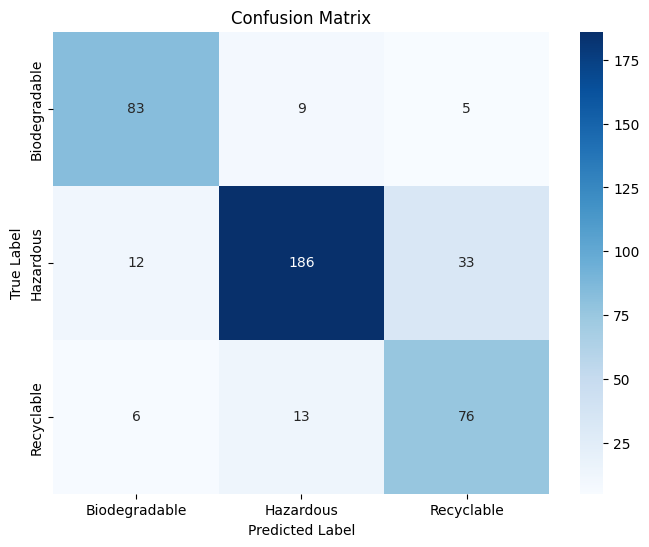

In [ ]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Confusion Matrix")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")

plt.show()

In [ ]:
import tensorflow as tf

model = tf.keras.models.load_model("/content/drive/MyDrive/waste_classifier (2).keras")

In [ ]:
model.save("waste_classifier.keras")

In [ ]:
from google.colab import files
files.download("waste_classifier.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
model.save("waste_classifier.keras")

In [1]:
import os

output_folder = "/content/drive/MyDrive/waste_project_outputs"

os.makedirs(output_folder, exist_ok=True)

print("Folder created:", output_folder)

Folder created: /content/drive/MyDrive/waste_project_outputs


In [2]:
import tensorflow as tf

model = tf.keras.models.load_model("/content/drive/MyDrive/waste_classifier.keras")

In [3]:
from google.colab import files

uploaded = files.upload()

Saving Screenshot 2026-03-07 105530.png to Screenshot 2026-03-07 105530.png


In [4]:
filename = list(uploaded.keys())[0]

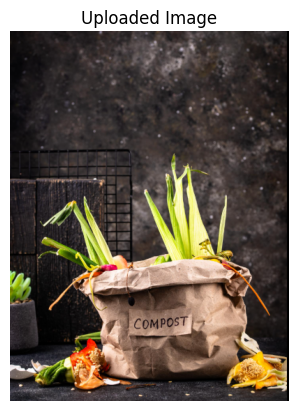

In [5]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open(filename)

plt.imshow(img)
plt.axis("off")
plt.title("Uploaded Image")
plt.show()

In [6]:
import numpy as np
from PIL import Image
import os
from tensorflow.keras.applications.efficientnet import preprocess_input
import shutil
import time

IMG_SIZE = (224,224)

class_names = ["Biodegradable","Hazardous","Recyclable"]

suggestions = {
"Biodegradable":"Dispose in compost bin",
"Recyclable":"Dispose in recycling bin",
"Hazardous":"Dispose in hazardous waste bin"
}

for filename in uploaded.keys():

    img = Image.open(filename).convert("RGB")
    img_resized = img.resize(IMG_SIZE)

    img_array = np.array(img_resized)
    img_array = preprocess_input(img_array)
    img_array = np.expand_dims(img_array, axis=0)

    preds = model.predict(img_array)

    predicted_class = class_names[np.argmax(preds)]
    confidence = float(np.max(preds)*100)

    suggestion = suggestions[predicted_class]

    print("Prediction:", predicted_class)
    print("Confidence:", f"{confidence:.2f}%")
    print("Suggestion:", suggestion)

    # save uploaded image to drive
    timestamp = int(time.time())
    save_path = os.path.join(output_folder, f"{timestamp}_{filename}")

    shutil.move(filename, save_path)

    print("Saved to:", save_path)

1/1 ━━━━━━━━━━━━━━━━━━━━ 15s 15s/step
Prediction: Biodegradable
Confidence: 98.66%
Suggestion: Dispose in compost bin
Saved to: /content/drive/MyDrive/waste_project_outputs/1773035718_Screenshot 2026-03-07 105530.png


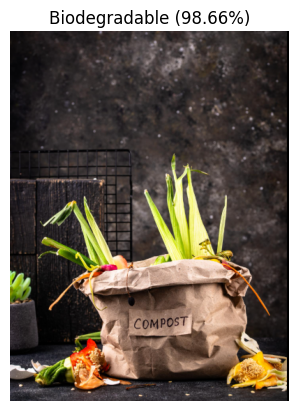

Suggestion: Dispose in compost bin
Saved to: /content/drive/MyDrive/waste_project_outputs/1773035718_Screenshot 2026-03-07 105530.png


In [7]:
import shutil

plt.imshow(img)
plt.title(f"{predicted_class} ({confidence:.2f}%)")
plt.axis("off")
plt.show()

print("Suggestion:", suggestions[predicted_class])

img.save(save_path)
print("Saved to:", save_path)

In [ ]:
import csv

log_file = "/content/drive/MyDrive/waste_project_outputs/predictions.csv"

with open(log_file, "a", newline="") as f:
    writer = csv.writer(f)
    writer.writerow([filename, predicted_class, confidence])

In [ ]:
#plt.imshow(Image.open(filename))
#plt.title(f"{predicted_class} ({confidence:.2f}%)")
#plt.axis("off")
#plt.show()

#print("Suggestion:", suggestions[predicted_class])